In [1]:
# Churn Prediction Project:
# Churn prediction means detecting which customers are likely to leave a service or to cancel a subscription.

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
df = pd.read_csv("data.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# when the number of columns is a lot, we can transpose the head of the dataframe to see all the columns:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [9]:
# first, let's clean the data:
df.columns = df.columns.str.lower().str.replace(pat= " ", repl= "_")
categorical_columns = list(df.dtypes[df.dtypes=="object"].index)

for category in categorical_columns:
    df[category] = df[category].str.lower().str.replace(pat=" ", repl="_")

df.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no_phone_service,no,no,no_phone_service,no
internetservice,dsl,dsl,dsl,dsl,fiber_optic
onlinesecurity,no,yes,yes,yes,no


In [10]:
# when looking at the data, we see that the column 'totalcharges' has numeric value, but its type is string(object):
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges         object
churn                object
dtype: object

In [11]:
# to fix this, we can use the to_numeric method of the pandas library:
pd.to_numeric(df.totalcharges)

ValueError: Unable to parse string "_" at position 488

In [14]:
# we see that we get an error while trying to convert the column.
# this is because in the initial dataset, the missing values where filled with spaces.
# then, we changed all the spaces to underscores, so it can't convert them to numeric values.
# we can use " errors='coerce' " to replace the non-convertable values with nan.
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges[df.totalcharges.isnull()]

488    NaN
753    NaN
936    NaN
1082   NaN
1340   NaN
3331   NaN
3826   NaN
4380   NaN
5218   NaN
6670   NaN
6754   NaN
Name: totalcharges, dtype: float64

In [15]:
# because there are only a few missing values, we can replace them with zeros:
df.totalcharges = df.totalcharges.fillna(0)

In [16]:
# for the churn value, we are interested in binary values, not yes and no:
df.churn = df['churn'].apply(lambda x: 1 if x == 'yes' else 0)

In [18]:
# setting up the validation framework:
# previously, we did the splitting using numpy and pandas.
# from now on, we will do this using scikit-learn library.
from sklearn.model_selection import train_test_split

In [285]:
# test_size = percentage of the test dataset
# random_state = the random seed 
df_train_plus_val, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_train_plus_val, test_size=0.25, random_state=1)

In [286]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [287]:
# resetting the indices:
df_train.reset_index(drop=True, inplace=True)
df_val.reset_index(drop=True, inplace=True)
df_test.reset_index(drop=True, inplace=True)
# extracting target variables:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values
# deleting the target variables from the dataframe:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [288]:
# now we do EDA using our df_train_plus_val:
df_train_plus_val.reset_index(drop=True, inplace=True)

In [289]:
# let's first look at the missing values:
df_train_plus_val.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [290]:
# we see that there are no missing values, so we don't need to do any data prepration here.
# so now, we look at the distribution of our target variable:
df_train_plus_val.churn.value_counts()

churn
0    4113
1    1521
Name: count, dtype: int64

In [291]:
# we can see around %25 of the users have stopped using our services(churned).
# we can see the exact percentage of the churns by using the parameter "normalize=True" :
df_train_plus_val.churn.value_counts(normalize=True)

churn
0    0.730032
1    0.269968
Name: proportion, dtype: float64

In [292]:
# we can see the exact churn rate is %26.3. 
# we could also use mean to find the churn rate, because all the churn values are ones.
# now, let's take a look at what numerical and categorical variables we have:
df_train_plus_val.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

In [293]:
# among the numerical values, we are interested in tenure (for how long has the customer used our services),
# monthly charges, and the total charges.
numerical = ["tenure", "monthlycharges", "totalcharges"] 
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents','phoneservice','multiplelines',
        'internetservice','onlinesecurity','onlinebackup','deviceprotection', 'techsupport',
        'streamingtv','streamingmovies', 'contract', 'paperlessbilling','paymentmethod']

In [294]:
# now let's see how many unique values do we have for each of the categorical variables:
df_train_plus_val[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [295]:
# EDA part two, Feature Importance:
# to find how important each categorical variable is, and how much effect it has, we can look at their churn rates explicitly.
churn_female = df_train_plus_val[df_train_plus_val.gender == "female"].churn.mean()
churn_female

np.float64(0.27682403433476394)

In [296]:
churn_male = df_train_plus_val[df_train_plus_val.gender == "male"].churn.mean()
churn_male

np.float64(0.2632135306553911)

In [297]:
# we see that there isn't much difference between the churn rate of women in comparison to men.
# so, the gender is not a useful categorical variable for predicting whether or not someone is going to churn.
# now let's check if the "partner" variable is useful for our prediction.
churn_no_partner = df_train_plus_val[df_train_plus_val.partner == "no"].churn.mean()
churn_no_partner

np.float64(0.3298090040927694)

In [298]:
churn_partner = df_train_plus_val[df_train_plus_val.partner == "yes"].churn.mean()
churn_partner

np.float64(0.20503330866025166)

In [299]:
# we see that there is indeed a lot of difference between the churn rates of thoese who have a partner and thoese who don't.
# so, using the 'partner' variable for predicting whether or not someone is going to churn, would be really useful.
# another way to assess whether or not a variable is useful for our model, is using Risk Rate.
# Risk Rate is defined as the group churn rate, devided by the global churn rate.
# if it's more than one, it means the variable has a negative impact, if it's approximately one it means the variable 
# doesen't have a large impact, and if it's less than one, it means the variable has a positive impact.
global_churn = df_train_plus_val.churn.mean()
churn_no_partner / global_churn

np.float64(1.2216593879412643)

In [300]:
# now, let's take a look at all the data we have, to see which variables to keep and which of them should we delete:
for category in categorical:
    print(category)
    df_group = df_train_plus_val.groupby(category).churn.agg(['mean', 'count'])
    df_group["diff"] = global_churn - df_group["mean"]
    df_group["risk"] = df_group["mean"] / global_churn
    display(df_group)
    print()
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
female,0.276824,2796,-0.006856,1.025396
male,0.263214,2838,0.006755,0.974980





seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,0.027698,0.897403
1,0.413377,912,-0.143409,1.531208





partner


...

,mean,count,diff,risk
contract,,,,
month-to-month,0.431701,3104,-0.161733,1.599082
one_year,0.120573,1186,0.149395,0.446621
two_year,0.028274,1344,0.241694,0.104730





paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
no,0.172071,2313,0.097897,0.637375
yes,0.338151,3321,-0.068183,1.252560





paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
bank_transfer_(automatic),0.168171,1219,0.101797,0.622928
credit_card_(automatic),0.164339,1217,0.105630,0.608733
electronic_check,0.455890,1893,-0.185922,1.688682
mailed_check,0.193870,1305,0.076098,0.718121


In [301]:
# Feature Importance: Mutual Information (tells us how much we can learn about one variable if we know the value of another)
# we don't need to implement this by ourselves, this has been implemented in scikit-learn:
from sklearn.metrics import mutual_info_score
mutual_info_score(df_train_plus_val.contract, df_train_plus_val.churn)

np.float64(0.0983203874041556)

In [302]:
mutual_info_score(df_train_plus_val.gender, df_train_plus_val.churn)

np.float64(0.0001174846211139946)

In [303]:
mutual_info_score(df_train_plus_val.partner, df_train_plus_val.churn) 

np.float64(0.009967689095399745)

In [304]:
# now, lets apply this to all our categorical variables to see which are more important for our prediction:
def mutual_info_score_churn(series):
    return mutual_info_score(series, df_train_plus_val.churn) 

In [305]:
mutual_information = df_train_plus_val[categorical].apply(mutual_info_score_churn)
mutual_information.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

In [306]:
# Now, we will take a look at the importance of our numerical values using correlation:
df_train_plus_val[numerical].corrwith(df_train_plus_val.churn)

tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [307]:
# Encoding the categorical variables:
# previously, we converted each categorical variable to some binary variables to encode them. 
# this encoding method is called the One-hot Encoding.
# we don't need to do this manually, because it has already been implemented in scikit-learn.
from sklearn.feature_extraction import DictVectorizer

In [308]:
train_dicts = df_train[categorical + numerical].to_dict(orient="records")
dv = DictVectorizer(sparse=False)
dv.fit(train_dicts)

DictVectorizer(sparse=False)

In [309]:
dv.transform(train_dicts)

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+01, 1.02155e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.00000e+00, 4.13650e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.00000e+00, 1.90050e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        2.70000e+01, 7.61950e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        9.00000e+00, 7.51650e+02]], shape=(4225, 45))

In [310]:
# this way we can check the name of the binary columns created.
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen',
       'streamingmovies=no', 'streamingmovies=no_internet_service',

In [311]:
# so now that we know how everything works, let's make our X matrix ready to train:
X_train = dv.fit_transform(train_dicts)

In [312]:
# now we repeat the process for the validation dataset:
val_dicts = df_val[categorical + numerical].to_dict(orient="records")
X_val = dv.transform(val_dicts)

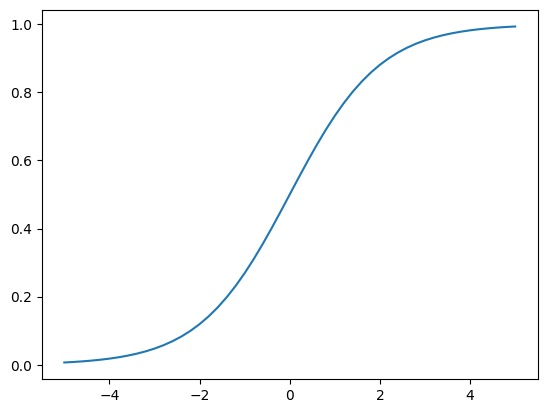

In [313]:
# now, let's define the sigmoid function that enables us to transform the problem,
# from the typical linear regression to logestic regression:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# let's draw the function to see how it looks:
z = np.linspace(-5, 5, 51)
output = sigmoid(z)
plt.plot(z, sigmoid(z))

In [314]:
def logestic_regression(xi):
    score = w0 

    for j in range(len(w)):
        score += xi[j] * w[j]

    result = sigmoid(score)
    return result

In [315]:
from sklearn.linear_model import LogisticRegression

In [316]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [317]:
# to see the coefficients found by the model, we can use model.coef_:
model.coef_[0].round(3)

array([ 0.681,  0.034, -0.677,  0.054, -0.016,  0.112, -0.159,  0.085,
        0.038, -0.   , -0.495,  0.692, -0.159, -0.018, -0.188,  0.068,
        0.158,  0.116, -0.159,  0.081,  0.283, -0.159, -0.086, -0.163,
        0.201, -0.045,  0.083, -0.053, -0.004,  0.107, -0.012,  0.068,
       -0.03 ,  0.194, -0.095, -0.159,  0.291, -0.055, -0.159,  0.252,
        0.233, -0.159, -0.037, -0.068,  0.   ])

In [318]:
# also, we can see the bias (also known as w0 or intercept), we can use model.intercept_:
model.intercept_[0].round(3)

np.float64(-0.047)

In [319]:
# now, to get the hard predictions, we can use model.predict(dataset),
# and to get the soft predictions (the probabilities), we can use model.predict_proba(dataset):
# we should note that the default threshold for the hard predictions to mark as a positive result is %50 (0.5).
model.predict(X_train)

array([0, 1, 1, ..., 1, 0, 1], shape=(4225,))

In [320]:
model.predict_proba(X_train)

array([[0.92683039, 0.07316961],
       [0.32394998, 0.67605002],
       [0.36940791, 0.63059209],
       ...,
       [0.48776366, 0.51223634],
       [0.97430701, 0.02569299],
       [0.3060625 , 0.6939375 ]], shape=(4225, 2))

In [321]:
# the previous output had two columns, the first one being the probabilty of being negative,
# and the second one, the probability of being positive.
# we are interested in the churning probability, so we can just keep the second column:
y_pred = model.predict_proba(X_train)[:, 1]
y_pred

array([0.07316961, 0.67605002, 0.63059209, ..., 0.51223634, 0.02569299,
       0.6939375 ], shape=(4225,))

In [322]:
y_pred_val = model.predict_proba(X_val)[:, 1]
y_pred_val

array([0.00668312, 0.20477927, 0.21762841, ..., 0.15135444, 0.78883516,
       0.81205432], shape=(1409,))

In [323]:
# now, we should evaluate our model to see how accurate it is:
churn_decision = (y_pred_val >= 0.5).astype(int)
accuracy = (churn_decision == y_val).mean()
accuracy

np.float64(0.8034066713981547)

In [324]:
# now let's gather all the information in one dataframe to compare the predictions and the actual values:
df_prediction = pd.DataFrame()
df_prediction["probability"] = y_pred_val
df_prediction["prediction"] = churn_decision
df_prediction["actual_values"] = y_val

In [325]:
df_prediction["correct"] = df_prediction.prediction == df_prediction.actual_values

In [326]:
df_prediction

,probability,prediction,actual_values,correct
0,0.006683,0,0,True
1,0.204779,0,0,True
2,0.217628,0,0,True
3,0.564239,1,1,True
4,0.218389,0,0,True
...,...,...,...,...
1404,0.291818,0,0,True
1405,0.041306,0,1,False
1406,0.151354,0,0,True
1407,0.788835,1,1,True


In [327]:
df_prediction.correct.mean()

np.float64(0.8034066713981547)

In [328]:
# now let's take a look at the coefficients one more time and try to understand and interprete them:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

{'contract=month-to-month': np.float64(0.681),
 'contract=one_year': np.float64(0.034),
 'contract=two_year': np.float64(-0.677),
 'dependents=no': np.float64(0.054),
 'dependents=yes': np.float64(-0.016),
 'deviceprotection=no': np.float64(0.112),
 'deviceprotection=no_internet_service': np.float64(-0.159),
 'deviceprotection=yes': np.float64(0.085),
 'gender=female': np.float64(0.038),
 'gender=male': np.float64(-0.0),
 'internetservice=dsl': np.float64(-0.495),
 'internetservice=fiber_optic': np.float64(0.692),
 'internetservice=no': np.float64(-0.159),
 'monthlycharges': np.float64(-0.018),
 'multiplelines=no': np.float64(-0.188),
 'multiplelines=no_phone_service': np.float64(0.068),
 'multiplelines=yes': np.float64(0.158),
 'onlinebackup=no': np.float64(0.116),
 'onlinebackup=no_internet_service': np.float64(-0.159),
 'onlinebackup=yes': np.float64(0.081),
 'onlinesecurity=no': np.float64(0.283),
 'onlinesecurity=no_internet_service': np.float64(-0.159),
 'onlinesecurity=yes': np.

In [329]:
# understanding this many features is quite hard, so let's train a smaller model:
small = ['contract', 'tenure', 'monthlycharges']
dicts_train_small = df_train[small].to_dict(orient="records")
dicts_val_small = df_val[small].to_dict(orient="records")

In [330]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

DictVectorizer(sparse=False)

In [331]:
X_train_small = dv_small.transform(dicts_train_small)

In [332]:
model_small = LogisticRegression()
model_small.fit(X_train_small, y_train)

LogisticRegression()

In [333]:
w0 = model_small.intercept_[0]
w0

np.float64(-2.477957596026966)

In [334]:
w = model_small.coef_[0].round(3)
w

array([ 0.971, -0.024, -0.948,  0.027, -0.036])

In [335]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

{'contract=month-to-month': np.float64(0.971),
 'contract=one_year': np.float64(-0.024),
 'contract=two_year': np.float64(-0.948),
 'monthlycharges': np.float64(0.027),
 'tenure': np.float64(-0.036)}

In [336]:
# now that we have understood the meaning of the coefficients, let's use the model:
dicts_train_plus_val = df_train_plus_val[categorical + numerical].to_dict(orient="records")
dv = DictVectorizer(sparse=False)
X_train_plus_val = dv.fit_transform(dicts_train_plus_val)
y_train_plus_val = df_train_plus_val.churn.values
model = LogisticRegression(max_iter=5000)
model.fit(X_train_plus_val, y_train_plus_val)

LogisticRegression(max_iter=5000)

In [337]:
dicts_test = df_test[categorical + numerical].to_dict(orient="records")
X_test = dv.transform(dicts_test)
y_pred_test = model.predict_proba(X_test)[:, 1]
churn_decision_test = (y_pred_test >= 0.5).astype(int)
(churn_decision_test == y_test).mean()

np.float64(0.8126330731014905)

In [338]:
random_customer = dicts_test[10]

In [339]:
X_customer = dv.transform([random_customer])

In [342]:
model.predict_proba(X_customer)[0][1]

np.float64(0.48055120159668036)

In [343]:
y_test[10]

np.int64(0)